# Práctica: Búsqueda de Hiperparámetros en Fashion MNIST

Para la base de datos Fashion MNIST, realizar una búsqueda de hiperparámetros que incluya:

1. Número adecuado de capas.
2. Número de neuronas por capa.
3. Tamaño del lote.
4. Learning Rate.

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import optuna
from optuna.samplers import RandomSampler

## Dataset

In [20]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

## Definición del modelo

In [21]:
# Definición del modelo
class SimpleNet(nn.Module):
    def __init__(self, n_layers, n_units, dropout_rate):
        super(SimpleNet, self).__init__()
        self.flatten = nn.Flatten()
        layers = []
        in_features = 28 * 28
        for i in range(n_layers):
            layers.append(nn.Linear(in_features, n_units[i]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_features = n_units[i]
        layers.append(nn.Linear(in_features, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(self.flatten(x))


## Definición de la sintonización de hiperparámetros

In [22]:
# La función objective recibe el obejto trial y retorna alguna medida de desempeño.
# Debe incluir la definición, entrenamiento y validación del modelo.
def objective(trial):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(torch.cuda.is_available())
    print(device)

    # Espacio de búsqueda.
    # Dependiendo del algoritmo de muestreo se eligen:
    # a) todos los valores.
    # b) valores al azar.
    # c) valores según algún criterio de búsqueda (Bayesian Optimization)

    n_layers = trial.suggest_int('n_layers', 1, 5)
    n_units = [trial.suggest_int(f'n_units_l{i}', 32, 256) for i in range(n_layers)]
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])

    # Definición del modelo.
    model = SimpleNet(n_layers, n_units, dropout_rate).to(device)

    # Se define el optimzador de acuerdo con la búsqueda.
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    else:
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # Función de costo.
    criterion = nn.CrossEntropyLoss()

    # Recordar que para la búsqueda de hiperparámetros se usan 3 conjuntos: Train,
    # Validation y Test.
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Ciclo de entrenamiento del modelo
    model.train()
    for epoch in range(5):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

    # Evaluación sobre el conjunto de validación
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

    # Se retorna el error, así que se búsca minimizar el error. Tmabién puede ser
    # que se quiera maximizar el accuracy.
    val_accuracy = correct / total
    return 1.0 - val_accuracy


In [23]:
# Se define el objeto study encargado de realizar la búsqueda. Por defecto se
# usa un sampler = TPESampler, pero puede usarse cualquiera en este listado:
# https://optuna-readthedocs-io.translate.goog/en/stable/tutorial/10_key_features/003_efficient_optimization_algorithms.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc#pruning
study = optuna.create_study(direction='minimize')
# study = optuna.create_study(direction='minimize', sampler=RandomSampler())
print(f"Sampler is {study.sampler.__class__.__name__}")
study.optimize(objective, n_trials=20) #Se pasa la función objective y se define
# la cantidad máxima de iteraciones.

[I 2026-05-24 00:20:39,437] A new study created in memory with name: no-name-66e3ea97-2662-4bc5-a275-a3bbbc507e70


Sampler is TPESampler
True
cuda


[I 2026-05-24 00:21:41,608] Trial 0 finished with value: 0.24958333333333338 and parameters: {'n_layers': 1, 'n_units_l0': 239, 'dropout_rate': 0.4812784354733931, 'learning_rate': 0.009257984440703576, 'optimizer': 'RMSprop', 'batch_size': 32}. Best is trial 0 with value: 0.24958333333333338.


True
cuda


[I 2026-05-24 00:22:52,040] Trial 1 finished with value: 0.28974999999999995 and parameters: {'n_layers': 4, 'n_units_l0': 122, 'n_units_l1': 39, 'n_units_l2': 82, 'n_units_l3': 63, 'dropout_rate': 0.3681329714763999, 'learning_rate': 0.005547595729476281, 'optimizer': 'Adam', 'batch_size': 32}. Best is trial 0 with value: 0.24958333333333338.


...

[I 2026-05-24 00:33:50,135] Trial 17 finished with value: 0.12816666666666665 and parameters: {'n_layers': 2, 'n_units_l0': 157, 'n_units_l1': 172, 'dropout_rate': 0.21757470805427864, 'learning_rate': 0.0004652189605618755, 'optimizer': 'Adam', 'batch_size': 256}. Best is trial 13 with value: 0.12541666666666662.


True
cuda


[I 2026-05-24 00:34:30,017] Trial 18 finished with value: 0.1293333333333333 and parameters: {'n_layers': 3, 'n_units_l0': 149, 'n_units_l1': 126, 'n_units_l2': 150, 'dropout_rate': 0.2500557491882073, 'learning_rate': 0.0013113563178100412, 'optimizer': 'Adam', 'batch_size': 128}. Best is trial 13 with value: 0.12541666666666662.


True
cuda


[I 2026-05-24 00:35:33,399] Trial 19 finished with value: 0.15425 and parameters: {'n_layers': 4, 'n_units_l0': 88, 'n_units_l1': 175, 'n_units_l2': 105, 'n_units_l3': 170, 'dropout_rate': 0.31674955392715376, 'learning_rate': 0.002756712746798335, 'optimizer': 'Adam', 'batch_size': 64}. Best is trial 13 with value: 0.12541666666666662.


## Visualización de resultados

In [24]:
print('Mejores parámetros encontrados:')
print(study.best_params)

Mejores parámetros encontrados:
{'n_layers': 3, 'n_units_l0': 172, 'n_units_l1': 170, 'n_units_l2': 146, 'dropout_rate': 0.2066647963185657, 'learning_rate': 0.0017971886557991631, 'optimizer': 'Adam', 'batch_size': 256}


/tmp/ipykernel_904/1317441400.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

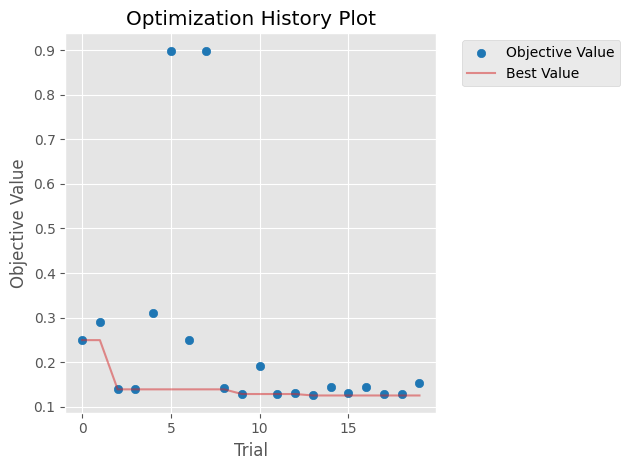

In [25]:
import optuna.visualization.matplotlib
optuna.visualization.matplotlib.plot_optimization_history(study)

In [26]:
optuna.visualization.plot_param_importances(study)

## Reentrenamiento del modelo con los mejores hiperparámetros y evaluación final sobre el conjunto de prueba.

In [27]:
# Extraer mejores hiperparámetros
best_params = study.best_params
n_layers = best_params['n_layers']
n_units = [best_params[f'n_units_l{i}'] for i in range(n_layers)]
dropout_rate = best_params['dropout_rate']
optimizer_name = best_params['optimizer']
learning_rate = best_params['learning_rate']
batch_size = best_params['batch_size']


In [28]:
# Reconstruir modelo final
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNet(n_layers, n_units, dropout_rate).to(device)

if optimizer_name == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
elif optimizer_name == 'RMSprop':
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
else:
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

criterion = nn.CrossEntropyLoss()


In [29]:
# Entrenar con todo el conjunto de entrenamiento
full_train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
num_epochs = 10

model.train()
for epoch in range(num_epochs):
    for data, target in full_train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()


In [30]:

# Evaluar en el conjunto de prueba
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

model.eval()
correct = 0
total = 0
test_loss = 0.0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        test_loss += criterion(output, target).item()
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

avg_test_loss = test_loss / len(test_loader)
test_accuracy = correct / total

print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test loss: {avg_test_loss:.4f}')

Test accuracy: 0.8764
Test loss: 0.3489
